In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Correlation section


In [ ]:
ener_corr = np.loadtxt('../resources/ener_corr.txt')

In [ ]:
ener_corr.shape

In [ ]:
print(ener_corr[50])

In [ ]:
plt.plot(ener_corr[50])

In [ ]:
def get_autocorrelation_function(signal : np.ndarray, norm : bool = True, mean : bool = True) -> np.ndarray:
    """
    Computes the autocorrelation function of a signal.

    Parameters
    ----------
    signal : np.ndarray
        Statistical signal to be autocorrelated.

    norm : bool
        Whether to compute normalized or unnormalized autocorrelation function.
        Default True.

    mean : np.ndarray
        Whether to subtract the mean from the signal.
        Default True.

    Returns
    -------
    autocorrelation_function : np.ndarray
        Autocorrelation function of the signal

    """

    #computing the lenght of the vectors
    M = len(signal)

    work_signal = signal.copy()
    if mean:
        work_signal -= np.mean(work_signal)

    #computing correlation
    autocorrelation_function = np.correlate(work_signal, work_signal, mode="full")[-M:]
    autocorrelation_function /= np.arange(M, 0, -1)

    #normalizing the autocorrelation function
    if norm:
        autocorrelation_function /= np.var(work_signal)
       
    return autocorrelation_function

In [ ]:
corr = np.zeros((10000,5000))
for i in range(ener_corr.shape[0]) :
	corr[i] = get_autocorrelation_function(ener_corr[i,:5000], norm=True, mean=False)

avg_corr = np.mean(corr, axis=0)

In [ ]:
corr_no_mean = np.zeros(ener_corr.shape)
for i in range(1000) :
	corr_no_mean[i] = get_autocorrelation_function(ener_corr[i], norm=True, mean=False)

avg_corr_no_mean = np.mean(corr_no_mean, axis=0)

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(ener_corr[0])
plt.plot(ener_corr[100])
plt.xlim(4500,5000)

In [ ]:
plt.plot(corr[0], label='corr 0')
plt.plot(corr[1], label='corr 1')

plt.plot(corr[50], label='corr 50')
plt.plot(corr[100], label='corr 100')

plt.legend()

In [ ]:
plt.plot(avg_corr)
plt.axhline(0, color='black', lw=1)

In [ ]:
diffusion_steps=10


for t in range(diffusion_steps - 1, 0, -1):
	print(f"{t} ; {diffusion_steps-t}")

# Animation view

In [ ]:
from IPython.display import HTML, display

def display_synced_gifs(gif_paths, width=400):
    paths_js = ','.join([f'"{p}"' for p in gif_paths])
    n = len(gif_paths)
    html = f"""
    <div style="display: flex; gap: 10px;">
        {''.join([f'<img id="gif{i}" width="{width}">' for i in range(n)])}
    </div>
    <script>
        (function() {{
            const paths = [{paths_js}];
            const gifs = paths.map((src, i) => document.getElementById("gif" + i));

            function fetchDuration(url) {{
                return fetch(url)
                    .then(r => r.arrayBuffer())
                    .then(buf => {{
                        const dv = new DataView(buf);
                        let pos = 0, duration = 0;
                        while (pos < dv.byteLength - 10) {{
                            if (dv.getUint8(pos) === 0x21 && dv.getUint8(pos + 1) === 0xF9) {{
                                duration += 10 * dv.getUint16(pos + 4, true);
                            }}
                            pos++;
                        }}
                        return duration;
                    }});
            }}

            Promise.all(paths.map(fetchDuration)).then(durations => {{
                const maxDuration = Math.max(...durations);
                const reload = () => {{
                    gifs.forEach((gif, i) => {{
                        gif.src = paths[i] + "?t=" + Date.now();
                    }});
                }};
                reload();
                setInterval(reload, maxDuration);
            }});
        }})();
    </script>
    """
    display(HTML(html))

In [ ]:
diff_steps = [50, 200, 1000]
paths = [f"../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds{step}.gif" for step in diff_steps]
display_synced_gifs(paths)

<table>
  <tr>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds50.gif" alt="anim diff_steps = 50"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds200.gif" alt="anim diff_steps = 200"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds1000.gif" alt="anim diff_steps = 1000"></td>
  </tr>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.5_ds50.png" alt="img diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.5_ds200.png" alt="img diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.5_ds1000.png" alt="img diff_steps = 1000"></td>
</table>

<table>
  <tr>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.2_ds50.gif" alt="anim diff_steps = 50"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.2_ds200.gif" alt="anim diff_steps = 200"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.2_ds1000.gif" alt="anim diff_steps = 1000"></td>
  </tr>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.2_ds50.png" alt="img diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.2_ds200.png" alt="img diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.2_ds1000.png" alt="img diff_steps = 1000"></td>
</table>

<table>
  <tr>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.01_ds50.gif" alt="anim diff_steps = 50"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.01_ds200.gif" alt="anim diff_steps = 200"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.01_ds1000.gif" alt="anim diff_steps = 1000"></td>
  </tr>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.01_ds50.png" alt="img diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.01_ds200.png" alt="img diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.01_ds1000.png" alt="img diff_steps = 1000"></td>
</table>

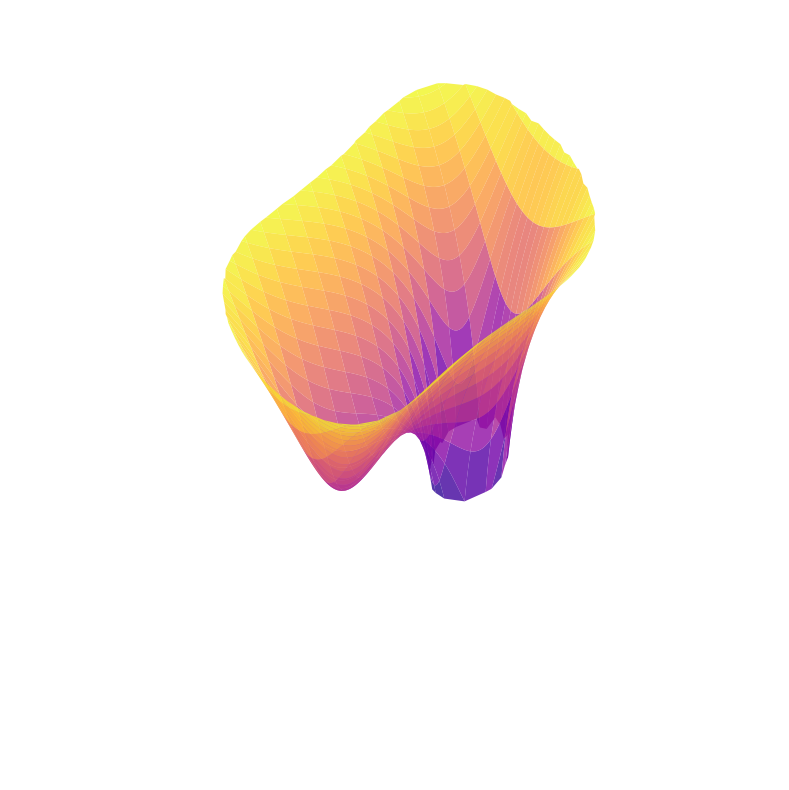

In [34]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Model parameters
eps = 3.0
c = 1.0
d = 0.5

def energy(x):
    if len(x.shape) < 2:
        return eps * (c * (x[0]**2 - 1)**2 + (x[0] - x[1])**2 + d * (x[0] + x[1]))
    else:
        return eps * (c * (x[:, 0]**2 - 1)**2 + (x[:, 0] - x[:, 1])**2 + d * (x[:, 0] + x[:, 1]))

# Grid range - reduced resolution for better performance
pos_min, pos_max = -6, 6
x_vals = torch.linspace(pos_min, pos_max, 600)  # Reduced from 1000 to 200
y_vals = torch.linspace(pos_min, pos_max, 600)
X, Y = torch.meshgrid(x_vals, y_vals, indexing='ij')
points = torch.stack([X.flatten(), Y.flatten()], dim=1)

Z = energy(points).reshape(X.shape)

# Define the energy range you want to visualize
min_energy = 0
max_energy = 40

# Create mask for points within energy range
energy_mask = (Z >= min_energy) & (Z <= max_energy)

# Apply mask to coordinates and energy values
X_masked = torch.where(energy_mask, X, torch.nan)
Y_masked = torch.where(energy_mask, Y, torch.nan)
Z_masked = torch.where(energy_mask, Z, torch.nan)


# Apply logarithmic scaling to handle large energy values
Z_log_masked = torch.where(energy_mask, torch.log10(Z_masked + 1), torch.nan)

# Create the plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface with masked values (NaN values won't be plotted)
surf = ax.plot_surface(X_masked.numpy(), Y_masked.numpy(), Z_log_masked.numpy(), 
                      cmap='plasma', alpha=0.8, edgecolor='none')

# Remove axes completely
ax.set_axis_off()

# Remove background panes and grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')

# Remove grid
ax.grid(False)

# Set transparent background for the figure
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Improve viewing angle
ax.view_init(elev=40, azim=60)

plt.tight_layout()

# Save with transparent background
plt.savefig('../resources/presentation/energy_surface.png', 
           transparent=True,           # Transparent background
           bbox_inches='tight',        # Remove extra whitespace
           pad_inches=0,              # No padding
           dpi=300)                   # High resolution

# Optional: also save as PDF (vector format)
plt.savefig('../resources/presentation/energy_surface.pdf', 
           transparent=True,
           bbox_inches='tight',
           pad_inches=0)

plt.show()

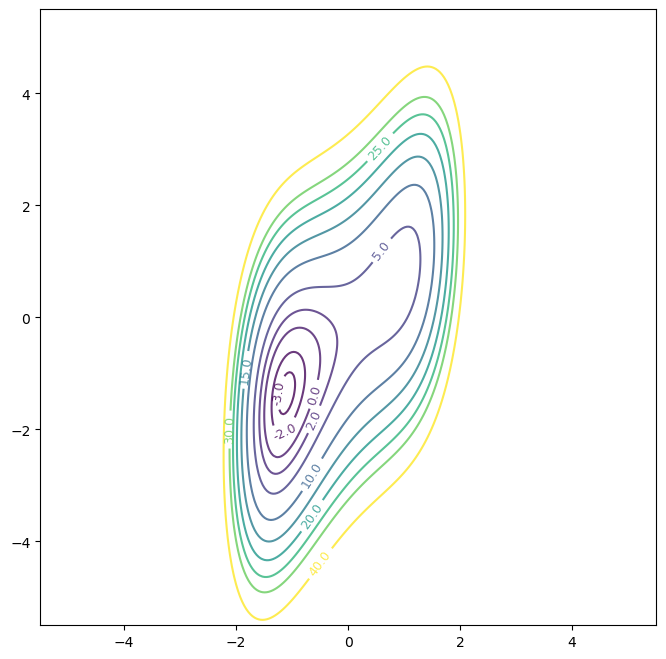

In [38]:
# Contour plotting function
def plot_contour_lines_only(output_dir, energy_levels=None, colors=None, 
                           linewidths=None, linestyles=None, alpha=0.8):
    """
    Plot specific contour lines only (no filled regions)
    
    Parameters:
    -----------
    output_dir : str
        Output directory and filename (without extension)
    energy_levels : list
        Specific energy levels to plot as contours
    colors : list or str
        Colors for each contour level
    linewidths : list or float
        Line widths for contours
    linestyles : list or str
        Line styles for contours
    alpha : float
        Transparency of contour lines
    """
    # Default energy levels if not provided
    if energy_levels is None:
        energy_levels = [-3, -2, 0, 2, 5, 10, 15, 20, 25, 30, 40]
    
    # Define grid for visualization
    upper_lim, lower_lim = 5.5, -5.5
    x = np.linspace(lower_lim, upper_lim, 300)
    y = np.linspace(lower_lim, upper_lim, 300)
    X, Y = np.meshgrid(x, y)

    # Compute energy landscape
    Z_target = np.zeros([len(X), len(Y)])
    for i in range(len(X)):
        for j in range(len(Y)):
            conf = torch.tensor([X[i][j], Y[i][j]], dtype=torch.float32)
            Z_target[i, j] = energy(conf).item()

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 8), dpi=100)

    # Set plot limits
    ax.set_xlim(lower_lim, upper_lim)
    ax.set_ylim(lower_lim, upper_lim)

    # Plot contour lines only
    contour = ax.contour(X, Y, Z_target, levels=energy_levels, 
                        colors=colors, alpha=alpha, 
                        linewidths=linewidths or 1.5,
                        linestyles=linestyles or '-')
    
    # Add contour labels
    ax.clabel(contour, inline=True, fontsize=9, fmt='%.1f')
    
    # Set labels
    #ax.set_xlabel('x', fontsize=12)
    #ax.set_ylabel('y', fontsize=12)
    #ax.set_title('Energy Contour Lines', fontsize=14)
    
    # Equal aspect ratio
    ax.set_aspect('equal')
    
    # Add grid for reference
    #ax.grid(True, alpha=0.3)
    
    # Save and close
    plt.savefig(output_dir + ".png", dpi=300, bbox_inches='tight')
    plt.show()  # Show instead of close for notebook

# Usage examples:
# Basic contour plot
plot_contour_lines_only("../resources/presentation/energy_contours")